# LAB 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

Importing Dataset

In [2]:
df1=pd.read_csv("CICIDS2017.csv")

Getting Basic Information

In [3]:
df1.shape

(56661, 78)

In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56661 entries, 0 to 56660
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Flow Duration                56661 non-null  int64  
 1   Total Fwd Packets            56661 non-null  int64  
 2   Total Backward Packets       56661 non-null  int64  
 3   Total Length of Fwd Packets  56661 non-null  int64  
 4   Total Length of Bwd Packets  56661 non-null  int64  
 5   Fwd Packet Length Max        56661 non-null  int64  
 6   Fwd Packet Length Min        56661 non-null  int64  
 7   Fwd Packet Length Mean       56661 non-null  float64
 8   Fwd Packet Length Std        56661 non-null  float64
 9   Bwd Packet Length Max        56661 non-null  int64  
 10  Bwd Packet Length Min        56661 non-null  int64  
 11  Bwd Packet Length Mean       56661 non-null  float64
 12  Bwd Packet Length Std        56661 non-null  float64
 13  Flow Bytes/s    

In [5]:
df1.describe()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,5.666100e+04,56661.000000,56661.000000,5.666100e+04,5.666100e+04,56661.000000,56661.000000,56661.000000,56661.000000,56661.000000,...,56661.000000,56661.000000,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04
mean,1.940740e+07,5.893348,5.441168,7.325051e+02,5.282417e+03,166.369390,10.105946,43.155072,57.334013,1552.609749,...,3.115794,26.955966,8.127717e+04,2.732128e+04,1.207459e+05,6.484220e+04,1.474432e+07,8.688159e+05,1.539940e+07,1.410650e+07
std,3.672377e+07,56.898685,66.513164,2.135208e+04,1.092694e+05,669.066176,47.856017,174.087067,224.747519,2773.907899,...,53.236039,6.796834,7.396278e+05,3.340568e+05,9.387816e+05,6.835563e+05,3.214172e+07,6.311718e+06,3.301473e+07,3.191101e+07
min,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.200000e+01,1.000000,1.000000,2.000000e+00,0.000000e+00,2.000000,0.000000,2.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.889700e+04,2.000000,2.000000,3.100000e+01,7.900000e+01,20.000000,0.000000,8.666667,0.000000,46.000000,...,1.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.813192e+06,5.000000,5.000000,2.800000e+02,4.830000e+03,195.000000,6.000000,47.625000,78.488853,1460.000000,...,2.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.200000e+08,6930.000000,9877.000000,2.866110e+06,2.150000e+07,23360.000000,1983.000000,5940.857143,7049.469004,11632.000000,...,5994.000000,60.000000,1.000000e+08,2.610000e+07,1.000000e+08,1.000000e+08,1.190000e+08,6.860000e+07,1.190000e+08,1.190000e+08


In [6]:
df1.describe(include='all')

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
count,5.666100e+04,56661.000000,56661.000000,5.666100e+04,5.666100e+04,56661.000000,56661.000000,56661.000000,56661.000000,56661.000000,...,56661.000000,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04,5.666100e+04,56661
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BENIGN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22731
mean,1.940740e+07,5.893348,5.441168,7.325051e+02,5.282417e+03,166.369390,10.105946,43.155072,57.334013,1552.609749,...,26.955966,8.127717e+04,2.732128e+04,1.207459e+05,6.484220e+04,1.474432e+07,8.688159e+05,1.539940e+07,1.410650e+07,NaN
std,3.672377e+07,56.898685,66.513164,2.135208e+04,1.092694e+05,669.066176,47.856017,174.087067,224.747519,2773.907899,...,6.796834,7.396278e+05,3.340568e+05,9.387816e+05,6.835563e+05,3.214172e+07,6.311718e+06,3.301473e+07,3.191101e+07,NaN
min,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
25%,7.200000e+01,1.000000,1.000000,2.000000e+00,0.000000e+00,2.000000,0.000000,2.000000,0.000000,0.000000,...,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
50%,5.889700e+04,2.000000,2.000000,3.100000e+01,7.900000e+01,20.000000,0.000000,8.666667,0.000000,46.000000,...,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
75%,8.813192e+06,5.000000,5.000000,2.800000e+02,4.830000e+03,195.000000,6.000000,47.625000,78.488853,1460.000000,...,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN


In [7]:
df1.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,4,2,0,37,0,31,6,18.500000,17.677670,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,142377,46,62,1325,105855,570,0,28.804348,111.407285,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,118873,23,28,1169,45025,570,0,50.826087,156.137367,2896,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,143577,43,55,1301,107289,570,0,30.255814,115.178969,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,143745,49,59,1331,110185,570,0,27.163265,108.067176,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
df1.isnull()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56656,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
56657,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
56658,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
56659,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
df1.isnull().sum()

Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 78, dtype: int64

Dealing with Missing Values

In [10]:
df1=df1.dropna()

In [11]:
df1.shape

(56607, 78)

Dealing with Noise

In [12]:
df1.replace([float('inf'), float('-inf')], float('nan'), inplace=True)

df1.dropna(inplace=True)

Outlier Detection and Treatment

In [13]:
for column in df1.columns:
    unique_values = df1[column].nunique()
    print(f"{column}:\t{unique_values} ")

Flow Duration:	33783 
Total Fwd Packets:	191 
Total Backward Packets:	219 
Total Length of Fwd Packets:	2511 
Total Length of Bwd Packets:	3519 
Fwd Packet Length Max:	1320 
Fwd Packet Length Min:	128 
Fwd Packet Length Mean:	4755 
Fwd Packet Length Std:	7427 
Bwd Packet Length Max:	1381 
Bwd Packet Length Min:	313 
Bwd Packet Length Mean:	4201 
Bwd Packet Length Std:	4628 
Flow Bytes/s:	35178 
Flow Packets/s:	35237 
Flow IAT Mean:	34249 
Flow IAT Std:	24263 
Flow IAT Max:	22907 
Flow IAT Min:	4756 
Fwd IAT Total:	15894 
Fwd IAT Mean:	19002 
Fwd IAT Std:	17167 
Fwd IAT Max:	16167 
Fwd IAT Min:	4383 
Bwd IAT Total:	15686 
Bwd IAT Mean:	18525 
Bwd IAT Std:	18034 
Bwd IAT Max:	16196 
Bwd IAT Min:	2706 
Fwd PSH Flags:	2 
Bwd PSH Flags:	1 
Fwd URG Flags:	2 
Bwd URG Flags:	1 
Fwd Header Length:	458 
Bwd Header Length:	492 
Fwd Packets/s:	34968 
Bwd Packets/s:	30923 
Min Packet Length:	111 
Max Packet Length:	1635 
Packet Length Mean:	7854 
Packet Length Std:	13473 
Packet Length Variance:	13

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


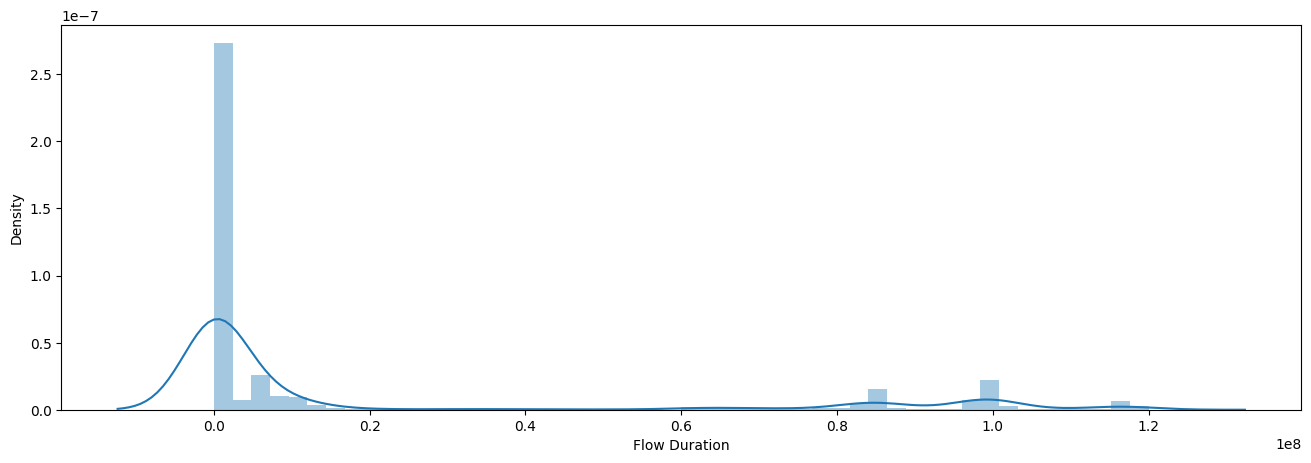

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


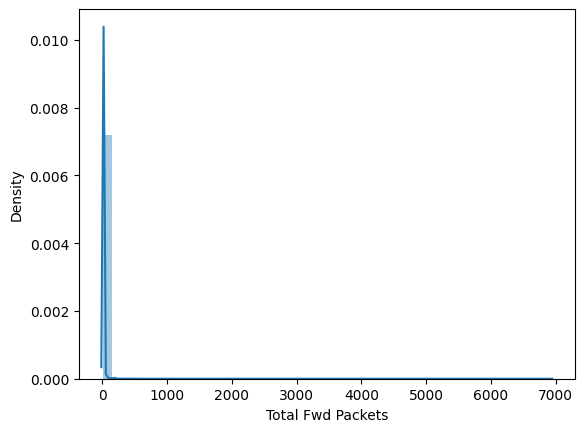

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


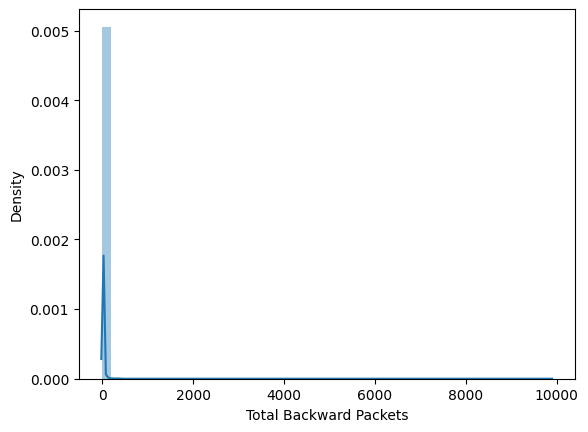

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


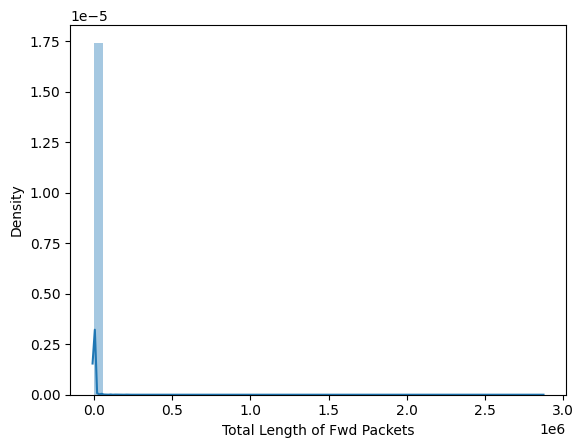

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


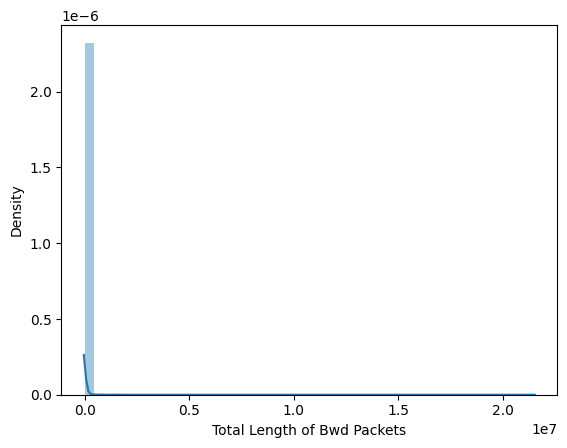

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


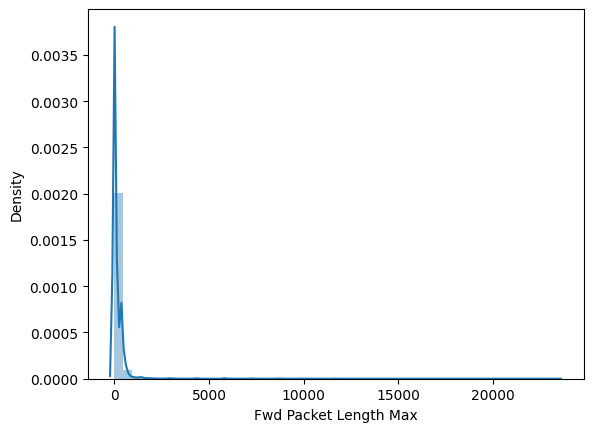

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


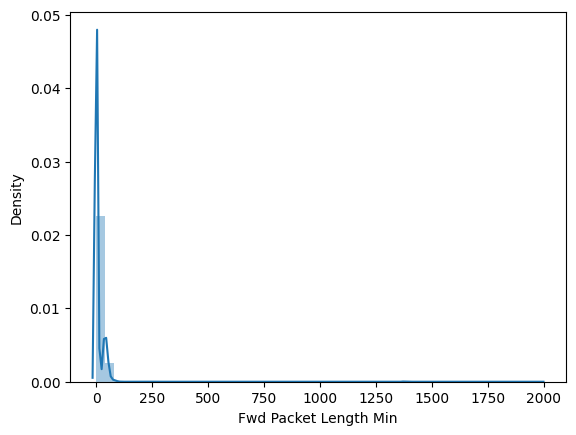

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


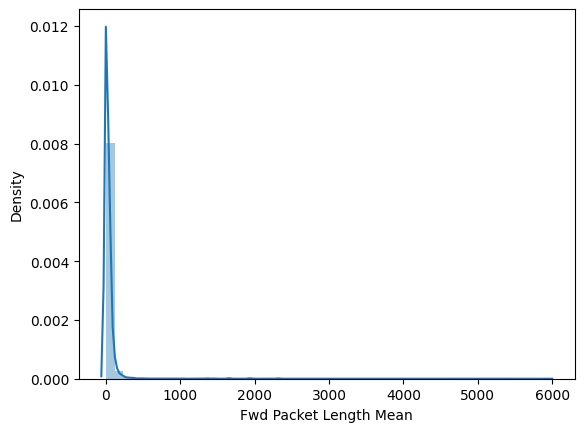

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


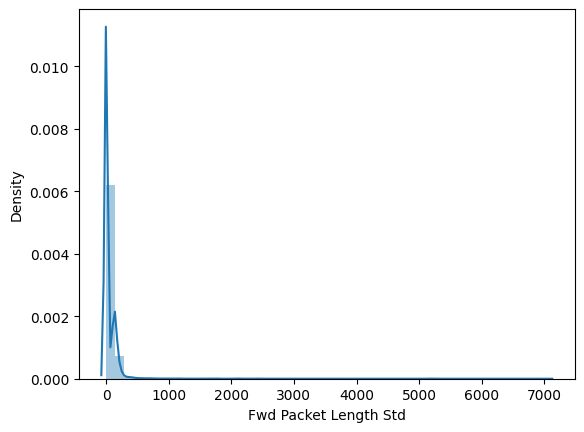

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


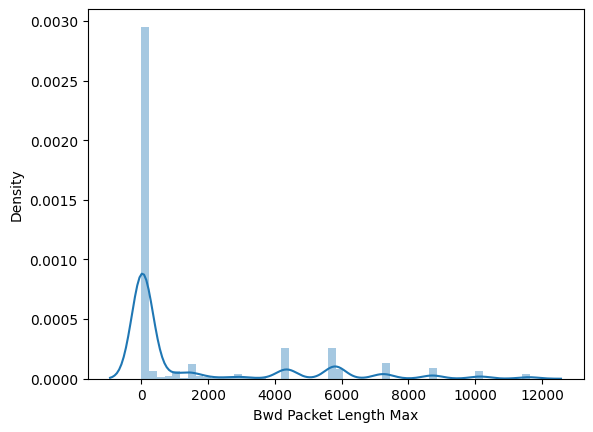

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


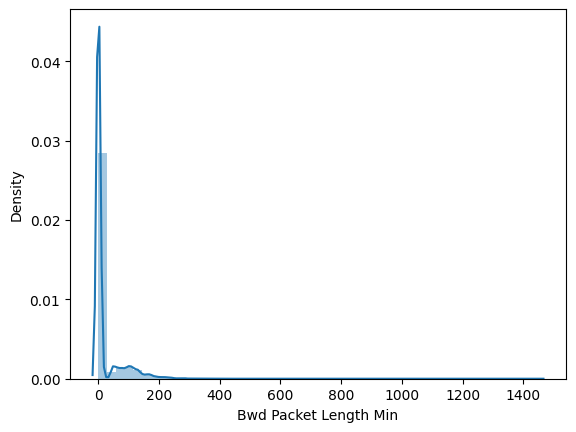

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


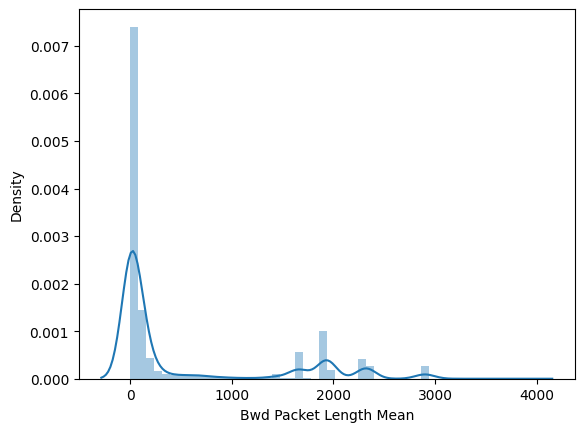

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


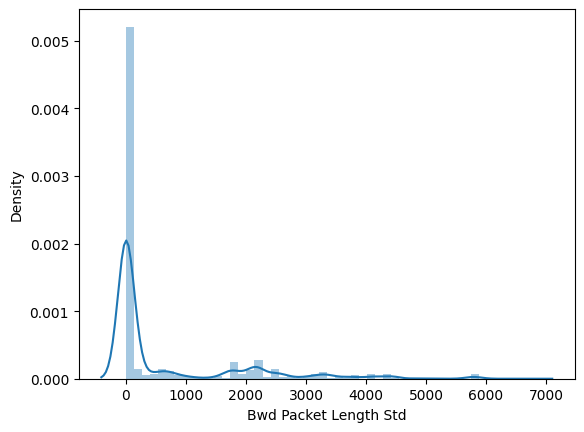

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


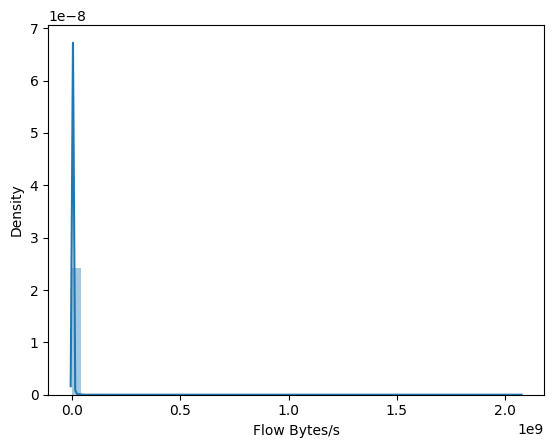

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


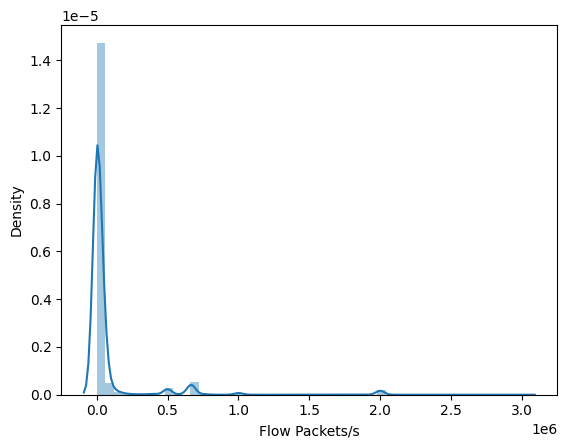

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


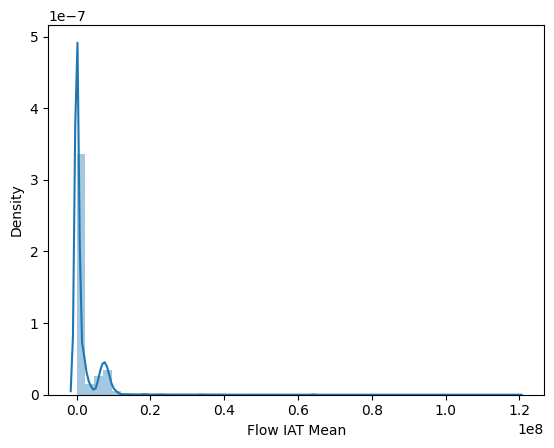

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


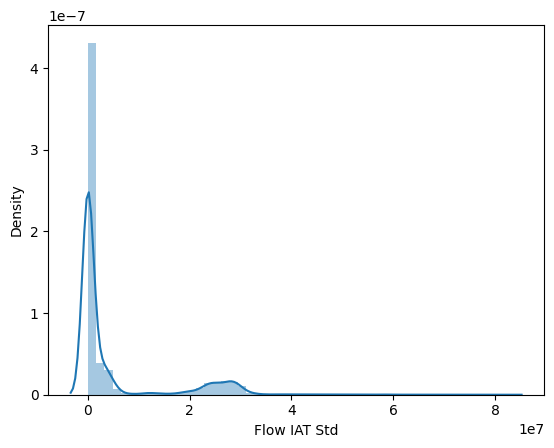

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


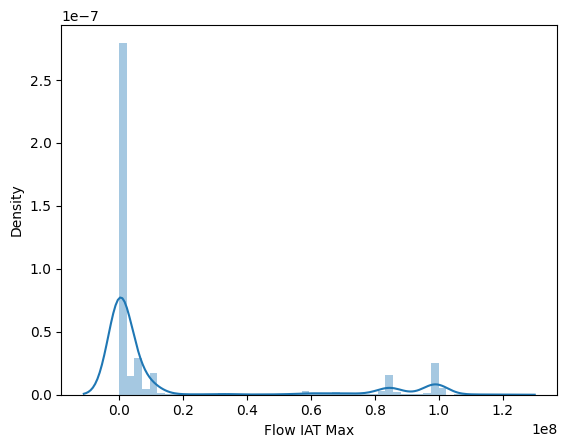

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


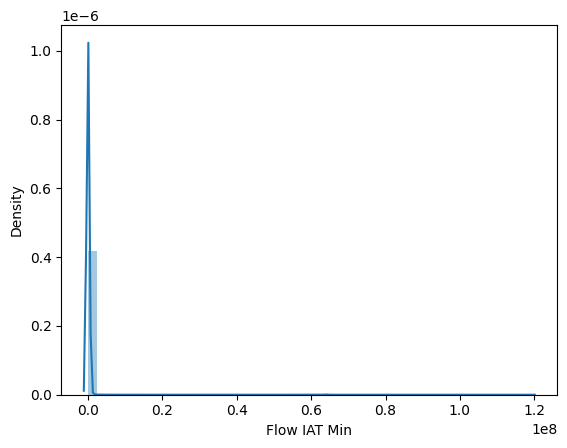

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


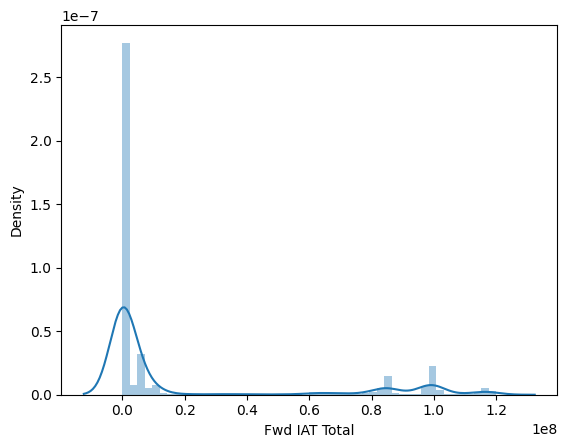

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


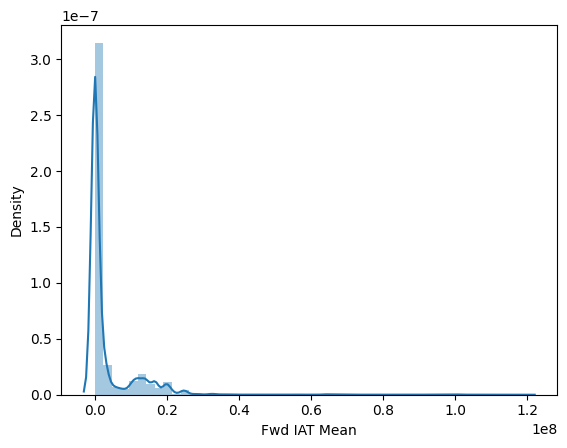

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


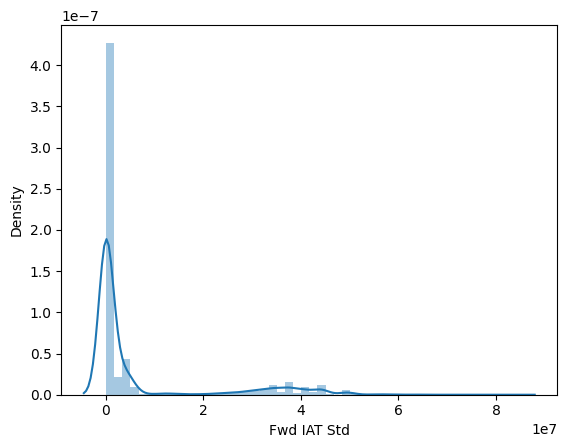

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


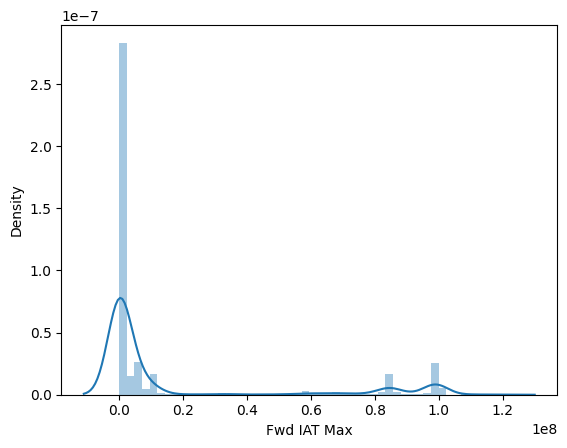

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


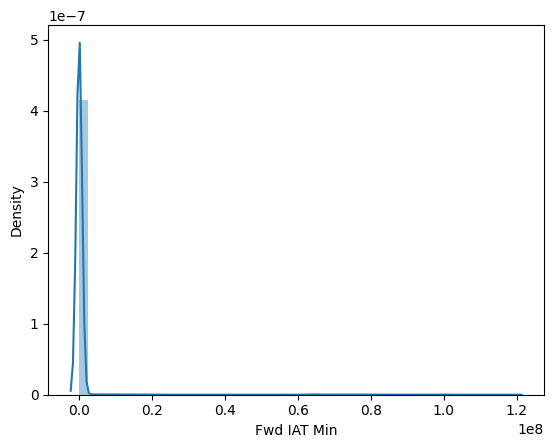

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


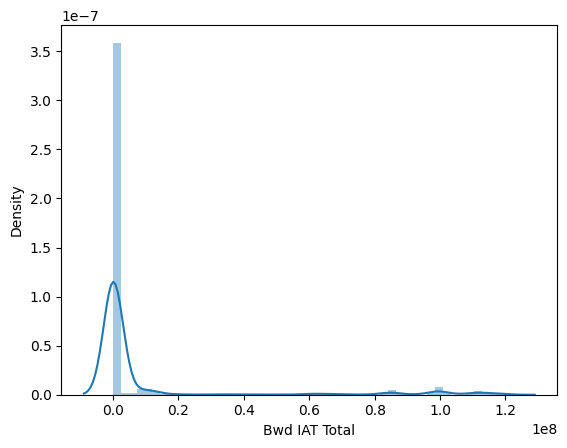

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


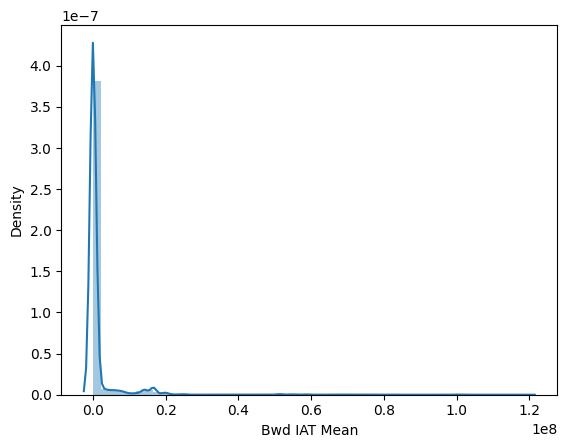

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


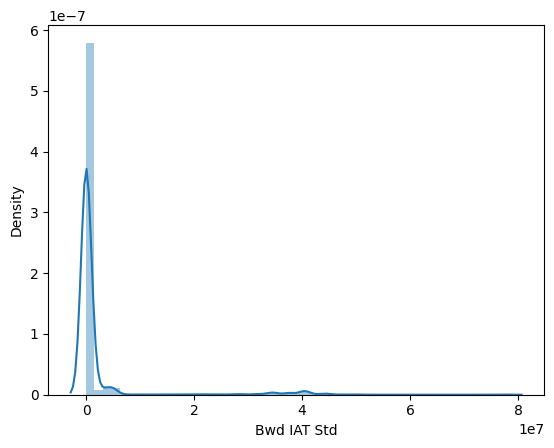

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


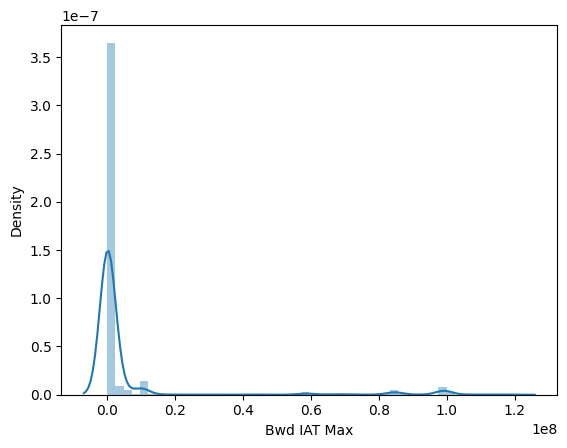

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


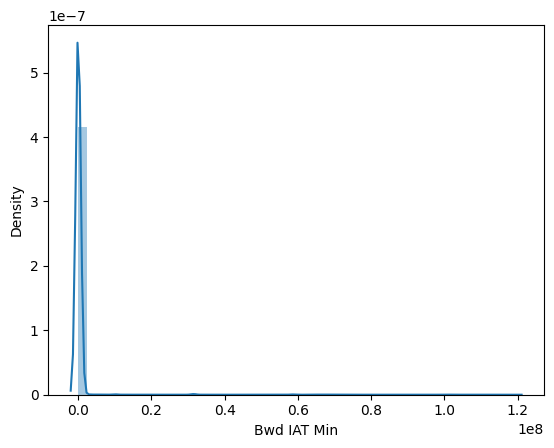

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


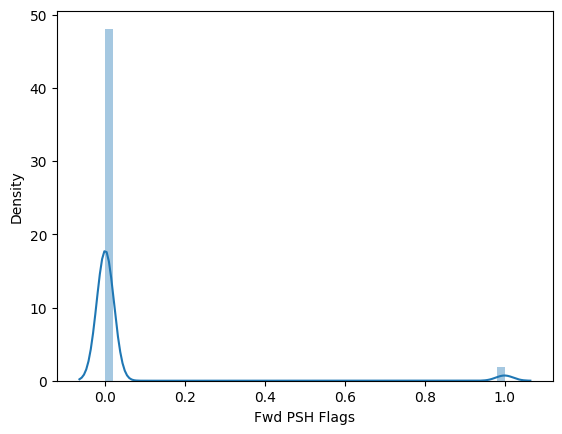

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])
C:\Users\DELL\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2517: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


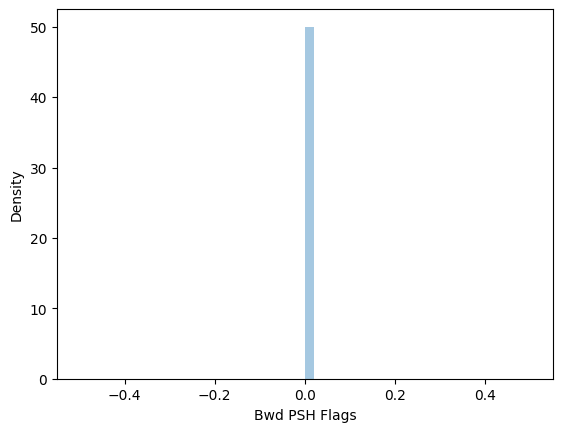

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


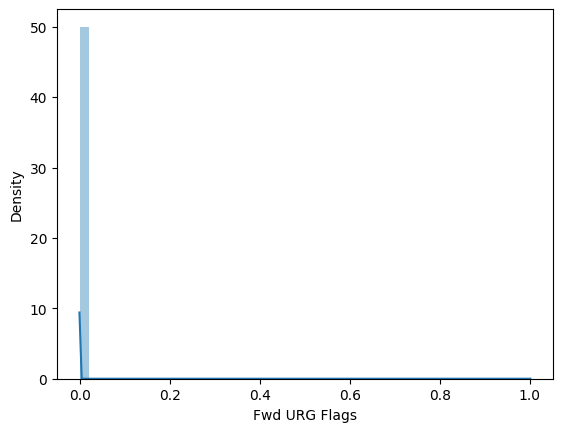

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])
C:\Users\DELL\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\distributions.py:2517: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


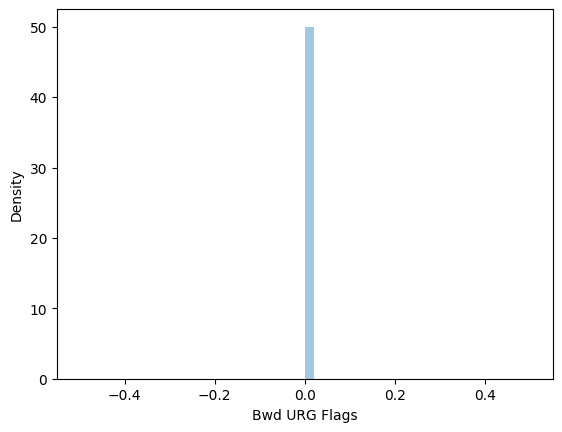

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


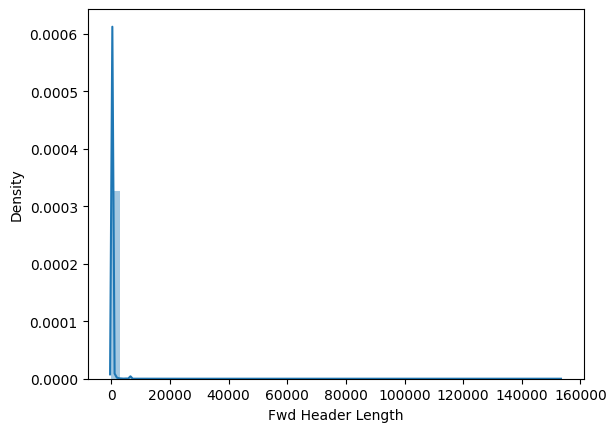

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


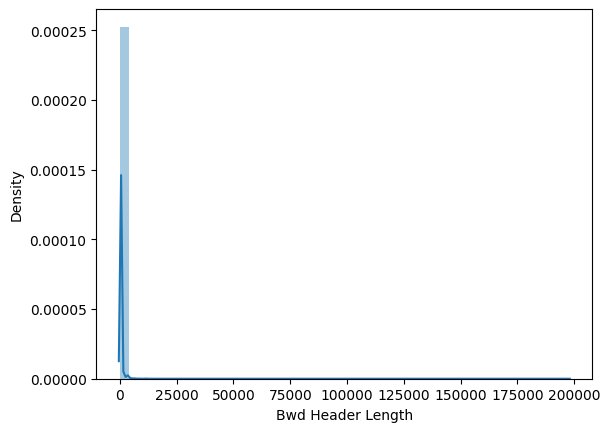

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


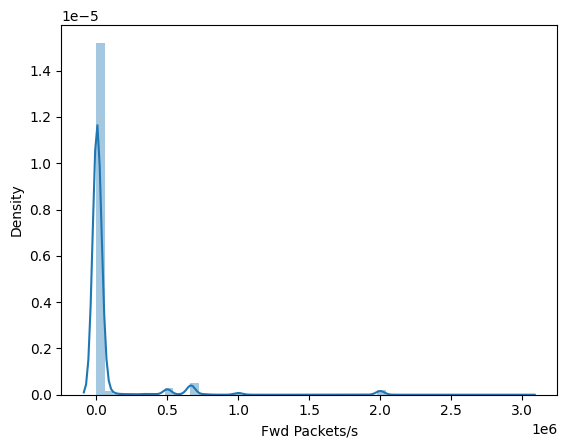

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


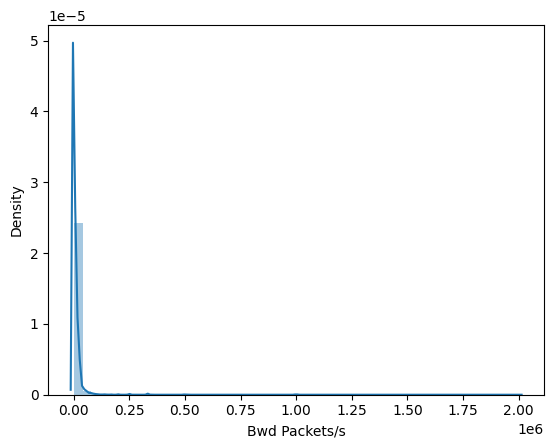

C:\Users\DELL\AppData\Local\Temp\ipykernel_25452\4054931549.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[column])


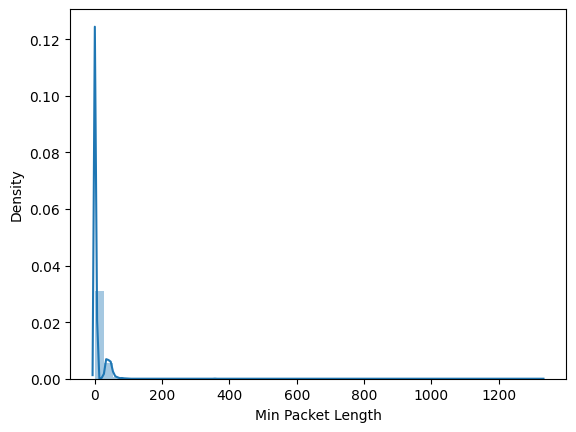

In [14]:
plt.figure(figsize=(16,5))
for column in df1.columns[:-40]:
    sns.distplot(df1[column])
    plt.show()

In [15]:
for column in df1.columns[:-1]: # removing outliers
    upper_limit = df1[column].quantile(0.99)
    lower_limit = df1[column].quantile(0.01)
    new_df = df1[ (df1[column] <= upper_limit) & (df1[column] >= lower_limit)]
new_df.shape

(56209, 78)

Splitting Dataset

In [16]:
data = new_df.iloc[:, :-1] 
labels = new_df.iloc[:, -1] 

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

Encoding Categorical Values

In [17]:
le = LabelEncoder()
le.fit(y_train)
y_train = le.transform(y_train)
y_test = le.transform(y_test)
y_train

array([3, 3, 3, ..., 0, 3, 5])

Feature Selection

In [18]:
for i in X_train.columns:
    if X_train[i].nunique() < 10:
        print(f"{i}: {X_train[i].nunique()}")  
zero_var_cols = []
for i in X_train.columns:
    if X_train[i].nunique() < 2:
          zero_var_cols.append(i)

Fwd PSH Flags: 2
Bwd PSH Flags: 1
Fwd URG Flags: 2
Bwd URG Flags: 1
FIN Flag Count: 2
SYN Flag Count: 2
RST Flag Count: 2
PSH Flag Count: 2
ACK Flag Count: 2
URG Flag Count: 2
CWE Flag Count: 2
ECE Flag Count: 2
Down/Up Ratio: 8
Fwd Avg Bytes/Bulk: 1
Fwd Avg Packets/Bulk: 1
Fwd Avg Bulk Rate: 1
Bwd Avg Bytes/Bulk: 1
Bwd Avg Packets/Bulk: 1
Bwd Avg Bulk Rate: 1
min_seg_size_forward: 8


In [19]:
# removing features with single value
X_train = X_train.drop(zero_var_cols, axis=1)
X_test = X_test.drop(zero_var_cols, axis=1)

In [20]:
X_train.shape

(44967, 69)

In [21]:
X_train.corr()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Flow Duration,1.000000,0.086346,0.072011,0.046421,0.046960,0.208923,-0.094042,0.106959,0.221901,0.584803,...,0.058083,-0.131358,0.150015,0.170251,0.211600,0.112765,0.884557,0.278544,0.900734,0.849810
Total Fwd Packets,0.086346,1.000000,0.979019,0.765370,0.632097,0.063761,-0.012724,0.048278,0.040294,0.035551,...,0.987599,-0.020761,0.080034,0.122717,0.107831,0.045005,0.019410,0.014008,0.021139,0.017308
Total Backward Packets,0.072011,0.979019,1.000000,0.650147,0.758116,0.064242,-0.009852,0.046090,0.039113,0.040097,...,0.961689,-0.019532,0.066684,0.102874,0.089690,0.037637,0.014409,0.008035,0.015206,0.013175
Total Length of Fwd Packets,0.046421,0.765370,0.650147,1.000000,0.016013,0.152804,-0.002975,0.159139,0.117422,-0.004760,...,0.806593,-0.016466,0.069371,0.094266,0.084636,0.042184,-0.001099,0.006098,-0.000011,-0.002033
Total Length of Bwd Packets,0.046960,0.632097,0.758116,0.016013,1.000000,0.022214,-0.009161,0.001980,0.009678,0.066027,...,0.574620,-0.018480,0.023080,0.035545,0.034375,0.014520,0.027454,0.008337,0.027758,0.026341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,0.112765,0.045005,0.037637,0.042184,0.014520,0.050580,-0.016831,0.046909,0.052937,0.059649,...,0.038550,0.002260,0.950753,0.051907,0.775042,1.000000,0.077340,0.037239,0.083776,0.071081
Idle Mean,0.884557,0.019410,0.014409,-0.001099,0.027454,0.143970,-0.081157,0.077018,0.176556,0.639454,...,0.003705,-0.129780,0.075956,0.010282,0.060625,0.077340,1.000000,0.128674,0.989634,0.989549
Idle Std,0.278544,0.014008,0.008035,0.006098,0.008337,0.061664,-0.027363,0.062572,0.076168,0.195921,...,0.013586,-0.091820,0.065180,0.094678,0.076024,0.037239,0.128674,1.000000,0.267753,-0.015416
Idle Max,0.900734,0.021139,0.015206,-0.000011,0.027758,0.148586,-0.082910,0.084302,0.182374,0.647767,...,0.005781,-0.137683,0.090652,0.037475,0.079453,0.083776,0.989634,0.267753,1.000000,0.958888


<function matplotlib.pyplot.show(close=None, block=None)>

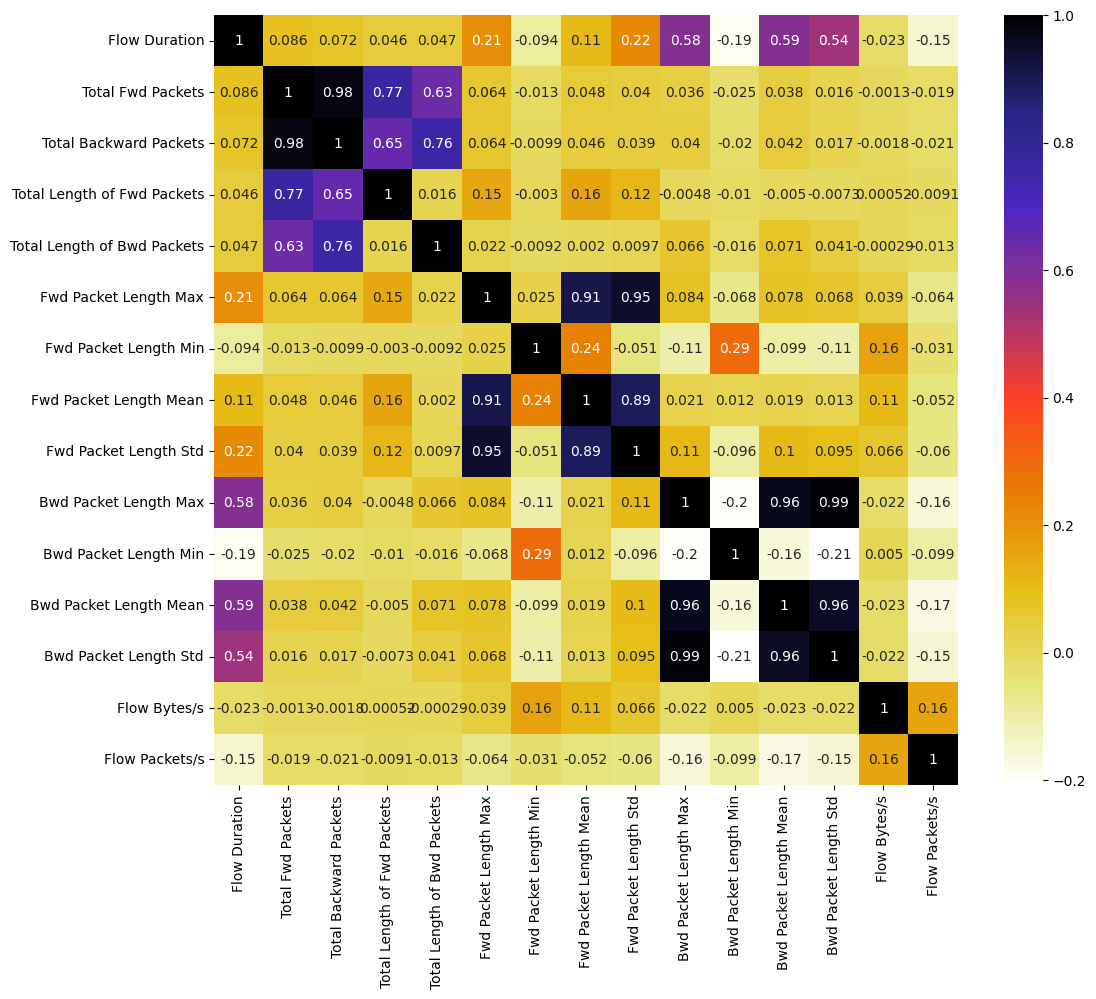

In [22]:
plt.figure(figsize=(12,10))
cor = X_train.iloc[:, :15].corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show

In [23]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i, j] > threshold: 
                colname = corr_matrix.columns[i]  
                col_corr.add(colname)
    return col_corr
corr_features = correlation(X_train, 0.80)
len(set(corr_features))

37

In [24]:
X_train = X_train.drop(corr_features, axis=1)
X_test = X_test.drop(corr_features, axis=1)

In [25]:
X_train.shape

(44967, 32)

<function matplotlib.pyplot.show(close=None, block=None)>

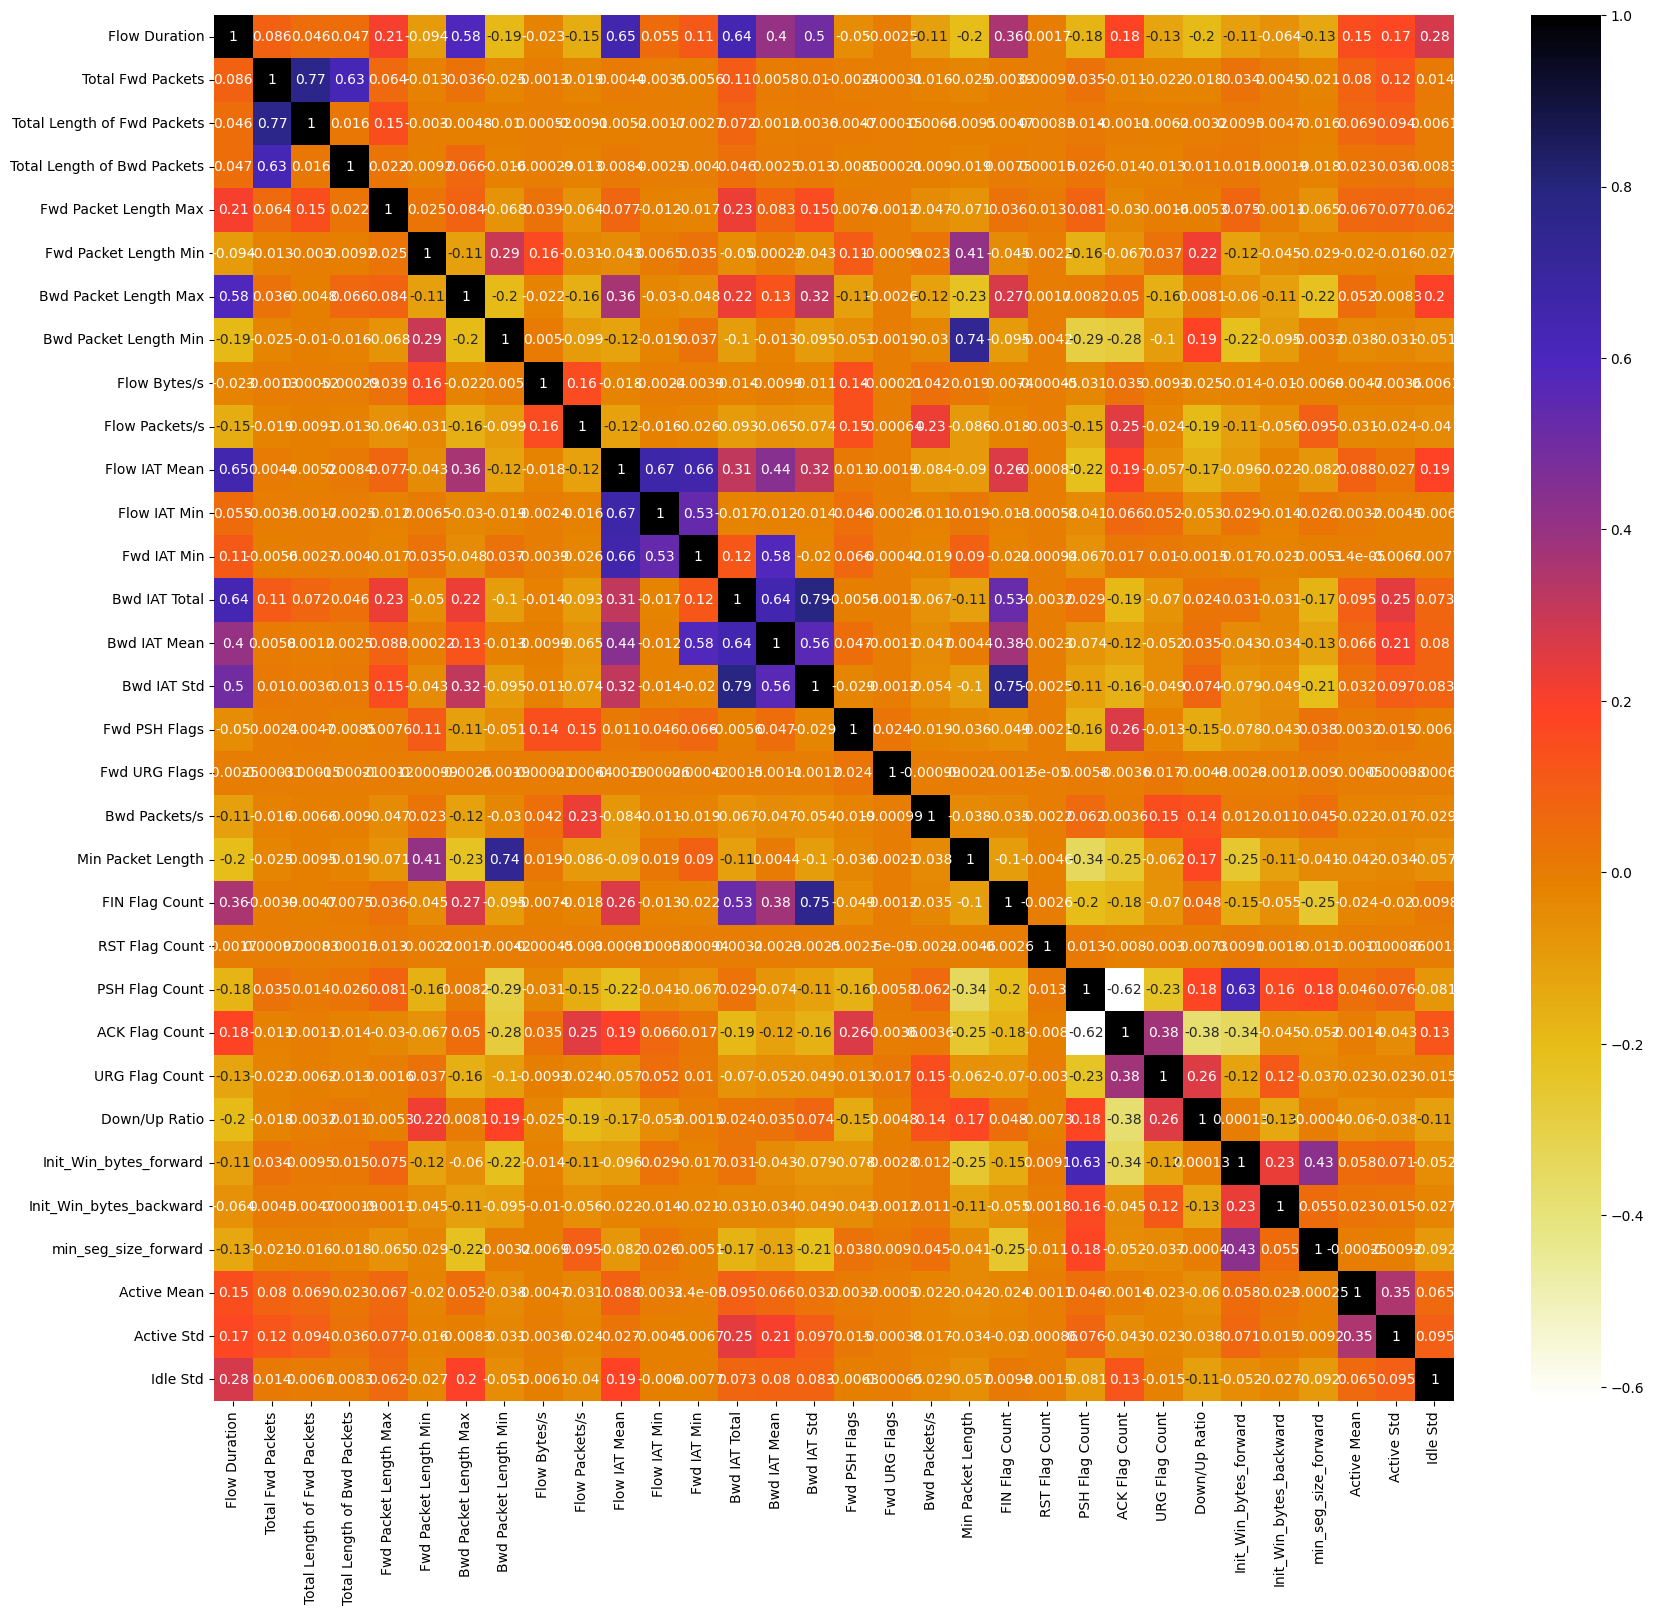

In [26]:
plt.figure(figsize=(20,18))
cor = X_train.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show

Feature Scaling

In [27]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [28]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)